In [15]:
import numpy as np
import pandas as pd 
import math 
import matplotlib.pyplot as plt 


In [16]:
# INITIALISE LATTICE: 

def create_grid(size, mode="random",seed=None,rng=None): 
    #creates an nxn numpy grid and initialises random parameters 

    if rng == None:
        rng = np.random.default_rng(seed)

    if mode == "random":
        grid = rng.choice([-1,1],size=(size,size))
    elif mode == "up":
        grid = np.ones((size,size), dtype=int)
    elif mode == "down":
        grid = -np.ones((size,size), dtype=int)
    else:
        raise ValueError("Mode must be: up, random, down")

    return grid 

# COMPUTE ENERGY AND BOUNDARY CONDITIONS (HAMILTONIAN): 

def total_energy(spins, J=1.0, h=0.0): 

    #computes periodic boundary conditions (wraps around)

    L = spins.shape[0]
    
    interaction = 0 
    for i in range(L):
        for j in range(L): 
            s = spins[i,j]
            right = spins[i, (j + 1) % L]
            down = spins[(i + 1) % L, j]
            interaction += -J * s * (right + down)

    field_term = -h * np.sum(spins)
    return interaction + field_term
    
# CALCULATE CHANGE IN ENERGY BY CHANGING ONE SPIN

def delta_energy(spins, i, j, J=1.0, h=0.0): 

    L = spins.shape[0]
    s = spins[i, j]

    # periodic neighbours
    up    = spins[(i - 1) % L, j]
    down  = spins[(i + 1) % L, j]
    left  = spins[i, (j - 1) % L]
    right = spins[i, (j + 1) % L]

    S = up + down + left + right

    return 2 * s * (J * S + h)

# CALCULATE MAGNETISATION

def magnetisation(spins):
    return np.mean(spins)

# RUN ONE METROPOLIS SWEEP (LxL)

def metropolis_sweep(spins, T, J=1.0, h=0.0, rng=None): 
    if rng is None:
        rng = np.random.default_rng()

    L = spins.shape[0]
    N = spins.size 

    for _ in range(N):
        i = rng.integers(0, L)
        j = rng.integers(0, L)

        dE = delta_energy(spins, i, j, J=J, h=h)

        if dE <= 0:
            spins[i, j] *= -1
        else:
            if rng.random() < np.exp(-dE / T):
                spins[i, j] *= -1

    return spins

# GET ROLLING VOLATILITY FROM RETURNS

def rolling_volatility(r, window=10):
    vol = np.full(len(r),np.nan)
    
    for t in range(window, len(r)):
        window_data = r[t-window:t]   # ONLY past values
        vol[t] = np.std(window_data)
        
    return vol

# RUN SIMULATION 

def run_simulation(
    L=75,
    T=2.27,
    J=1.0,
    h=0.0,
    n_equil=1000,
    n_steps=1500,
    sample_freq=10,
    init_mode="random",
    seed=None
):
    rng = np.random.default_rng(seed)
    spins = create_grid(L,mode=init_mode, seed=seed,rng=rng)

    # allows lattice to move towards thermal equilibirum to reduce dependance on arbitrary starting configuration
    for i in range(n_equil):
        metropolis_sweep(spins, T, J=J, h=h, rng=rng)

    print(f"Random Lattice Initialised: Temp = {T}")

    mags = []
    energies = []
    first_returns = []
    rolling_vol = []

    for i in range(n_steps):
        metropolis_sweep(spins, T, J=J, h=h, rng=rng)
        if i%sample_freq == 0:
            current_mags = magnetisation(spins)
            if len(mags)>0:
                first_returns.append(current_mags - mags[-1])
                rolling_vol.append(rolling_volatility(first_returns))
            energies.append(total_energy(spins,J=J,h=h))
            mags.append(current_mags)

    print(f"Simulation Complete: Temp = {T}")

    return spins, np.array(mags), np.array(energies), np.array(first_returns), np.array(rolling_volatility)



In [ ]:
#RUN THE SIMULATION AT SEVERAL TEMPERATURES AND EXTRACT BASIC METRICS: 

temps = [1, 1.5, 2, 2.269, 2.5, 3, 4, 6.5]
results = {}
L = 60

for t in temps: 
    spins, mags, energies, first_returns,rolling_vol = run_simulation(L=L,T=t,J=1.0,h=0.0,n_equil=2000,n_steps=15000,sample_freq=15,init_mode="random",seed=None)   

    average_mag = np.mean(mags)
    abs_average_mag = np.mean(np.abs(mags))
    susceptibility = L**2/t*(np.mean(mags**2)-average_mag**2)
    heat_capacity = 1/(L**2 * t**2) * (np.mean(energies**2) - np.mean(energies)**2)
    u4 = 1 - (np.mean(mags**4)/(3*np.mean(mags**2)**2))

    results[t] = {f"Magnetisation": mags,"Average_Mag":average_mag,"Abs_Average_Mag":abs_average_mag,"Energies":energies, "First_Return":first_returns, "Rolling_Vol":rolling_vol, "Spins": spins.copy(),"Susceptibility":susceptibility, "Heat_Capacity":heat_capacity, "Binder_Cumulant": u4 }



Random Lattice Initialised: Temp = 1
Simulation Complete: Temp = 1
Random Lattice Initialised: Temp = 1.5
Simulation Complete: Temp = 1.5
Random Lattice Initialised: Temp = 2


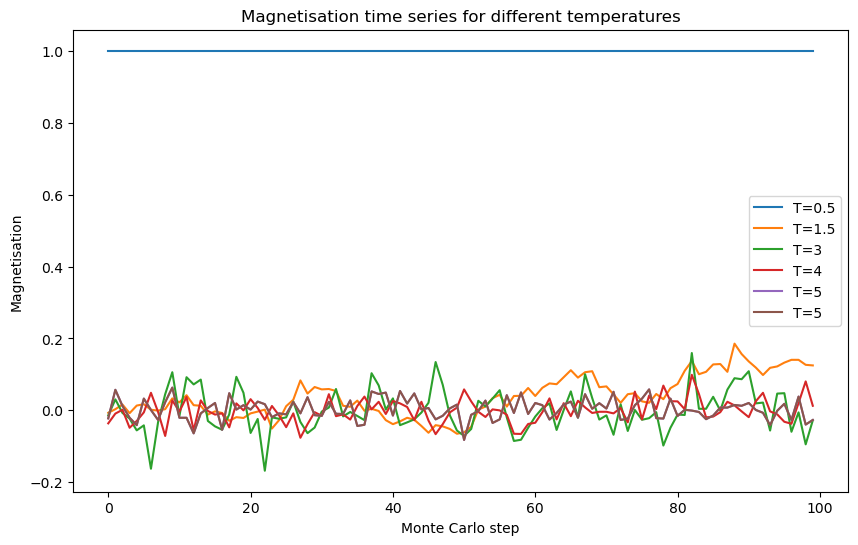

In [ ]:
#PLOT MAGNETISATION (MARKET SENTIMENT) AT DIFFERENT TEMPERATURES 
plot_t = [1, 2.269, 6.5]

plt.figure(figsize=(10, 6))
for t in plot_t:
    plt.plot(results[t]["Magnetisation"], label=f"T={t}")
plt.xlabel("Monte Carlo step")
plt.ylabel("Magnetisation")
plt.title("Magnetisation time series for different temperatures")
plt.legend()
plt.show()

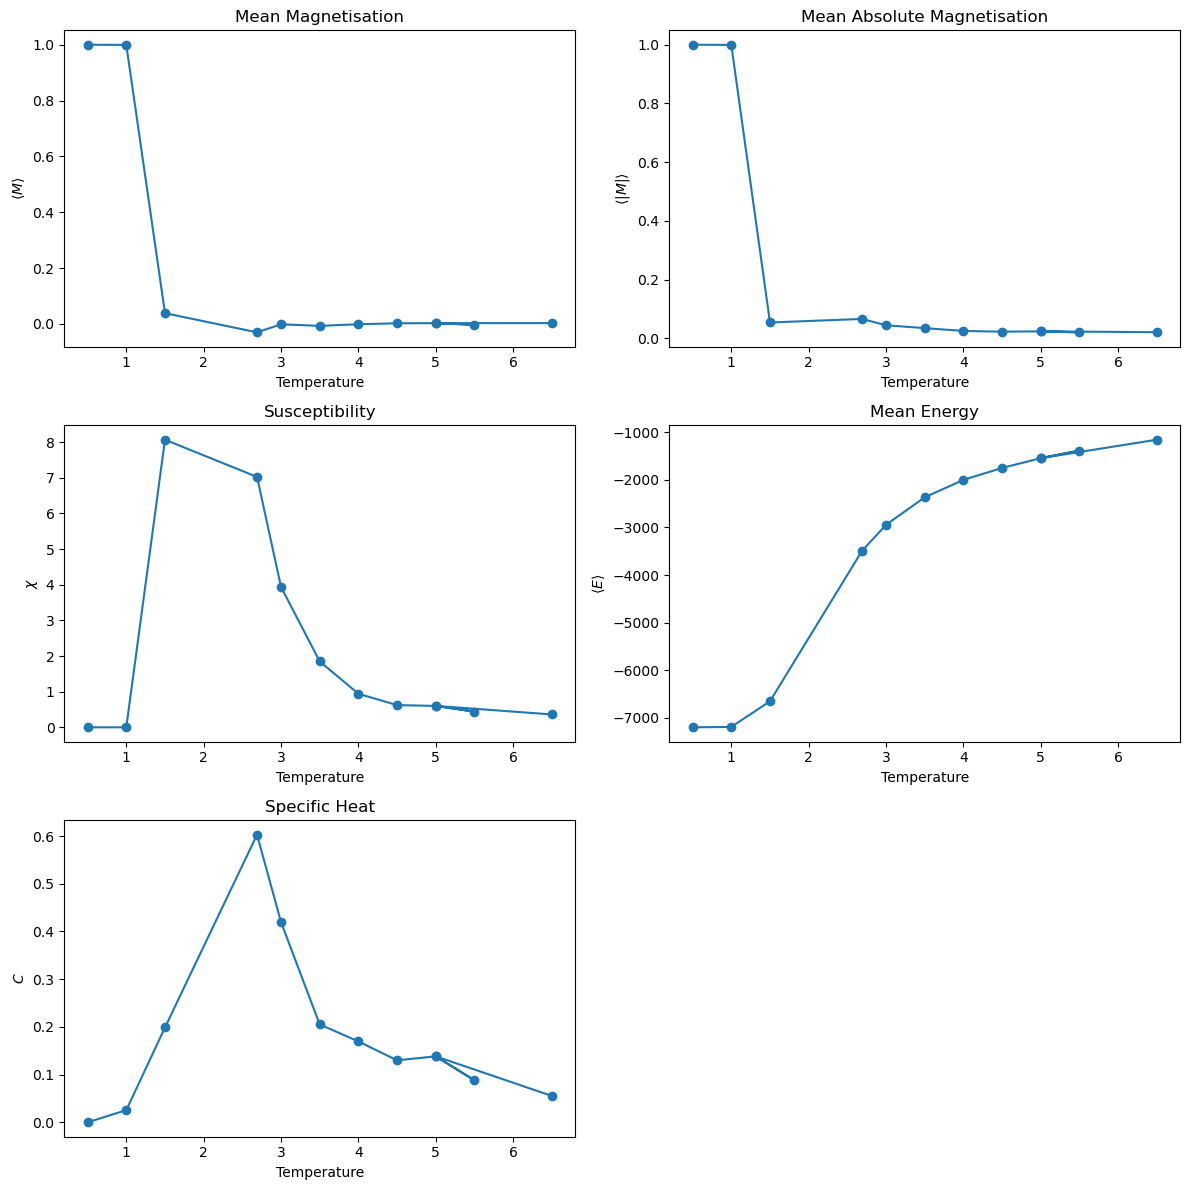

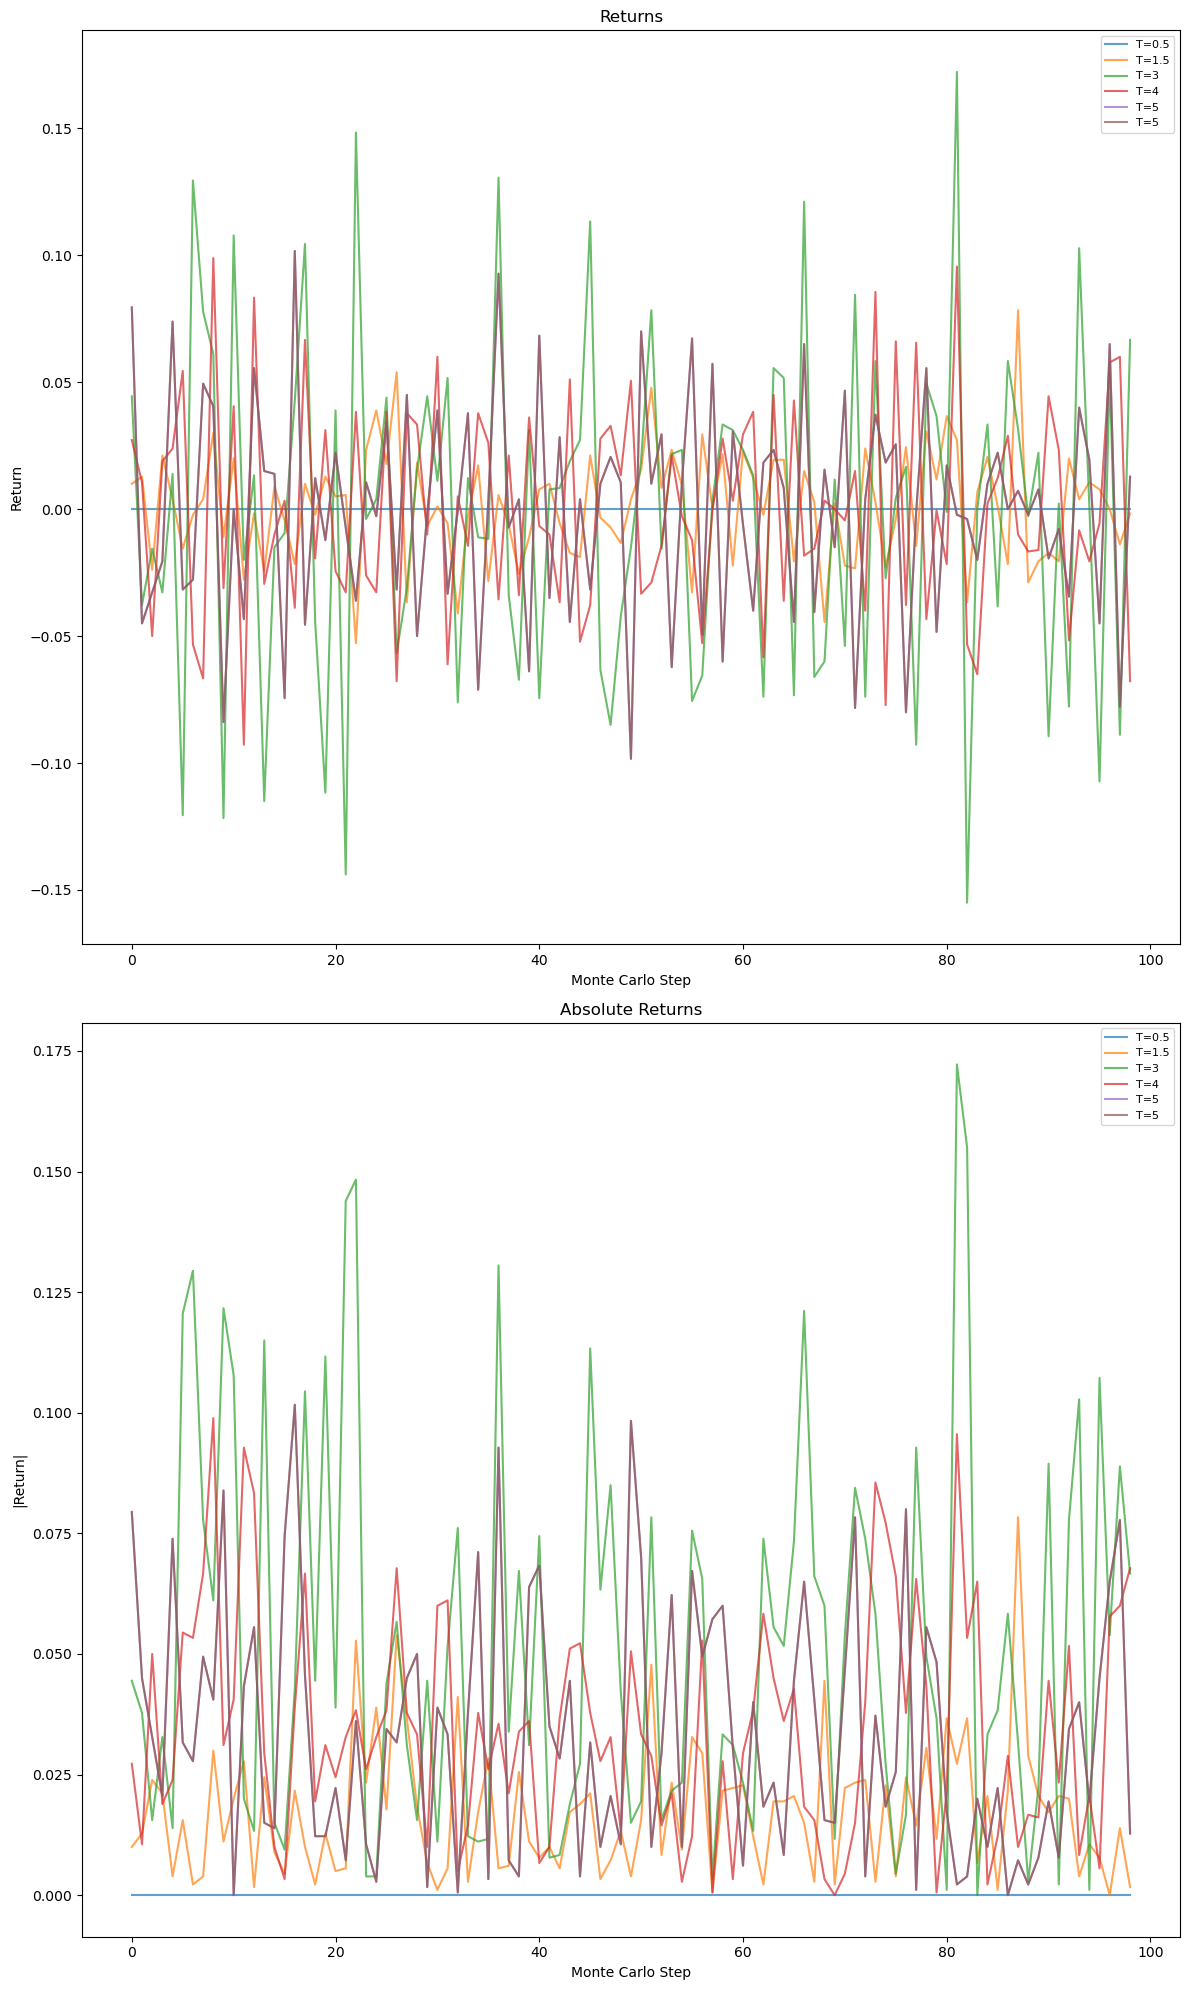

In [ ]:

#EXTRACT VALUES INTO LISTS FOR PLOTTING 

average_mag = []
abs_average_mag = []
susceptibility = []
average_energy = []
specific_heat = []
first_returns = []
abs_first_return = []
binder_cumulant = []


for t in temps:
    average_mag.append(results[t]["Average_Mag"])
    abs_average_mag.append(results[t]["Abs_Average_Mag"])
    susceptibility.append(results[t]["Susceptibility"])
    average_energy.append(np.mean(results[t]["Energies"]).item())
    specific_heat.append(results[t]["Heat_Capacity"])
    binder_cumulant.append(results[t]["Binder_Cumulant"])
    

#PLOT DIFFERENT METRICS 

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

# 1. Mean Magnetisation
axes[0].plot(temps, average_mag, marker="o")
axes[0].set_title("Mean Magnetisation")
axes[0].set_xlabel("Temperature")
axes[0].set_ylabel(r"$\langle M \rangle$")

# 2. Mean Absolute Magnetisation
axes[1].plot(temps, abs_average_mag, marker="o")
axes[1].set_title("Mean Absolute Magnetisation")
axes[1].set_xlabel("Temperature")
axes[1].set_ylabel(r"$\langle |M| \rangle$")

# 3. Susceptibility
axes[2].plot(temps, susceptibility, marker="o")
axes[2].set_title("Susceptibility")
axes[2].set_xlabel("Temperature")
axes[2].set_ylabel(r"$\chi$")

# 4. Mean Energy
axes[3].plot(temps, average_energy, marker="o")
axes[3].set_title("Mean Energy")
axes[3].set_xlabel("Temperature")
axes[3].set_ylabel(r"$\langle E \rangle$")

# 5. Specific Heat
axes[4].plot(temps, specific_heat, marker="o")
axes[4].set_title("Specific Heat")
axes[4].set_xlabel("Temperature")
axes[4].set_ylabel(r"$C$")

# 6. Empty subplot (turn it off so it doesn't look stupid)
axes[5].axis(temps, binder_cumulant, marker="o")
axes[4].set_title("Binder Cumulant")
axes[4].set_xlabel("Temperature")
axes[4].set_ylabel(r"$C$")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 20))

# Left: Returns
for t in temps[::2]:
    axes[0].plot(results[t]["First_Return"], alpha=0.7, label=f"T={t}")
axes[0].set_title("Returns Time Series")
axes[0].set_xlabel("Monte Carlo Step")
axes[0].set_ylabel("Return")
axes[0].legend(fontsize=8)

# Right: Rolling Volatility
for t in temps[::2]:
    axes[1].plot(np.abs(results[t]["First_Return"]), alpha=0.7, label=f"T={t}")
axes[1].set_title("Rolling Volatility Time Series")
axes[1].set_xlabel("Monte Carlo Step")
axes[1].set_ylabel("Rolling Volatility")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

C:\Users\joven\AppData\Local\Temp\ipykernel_34904\1625091206.py:11: RuntimeWarning: invalid value encountered in divide
  acf = acf / acf[0]


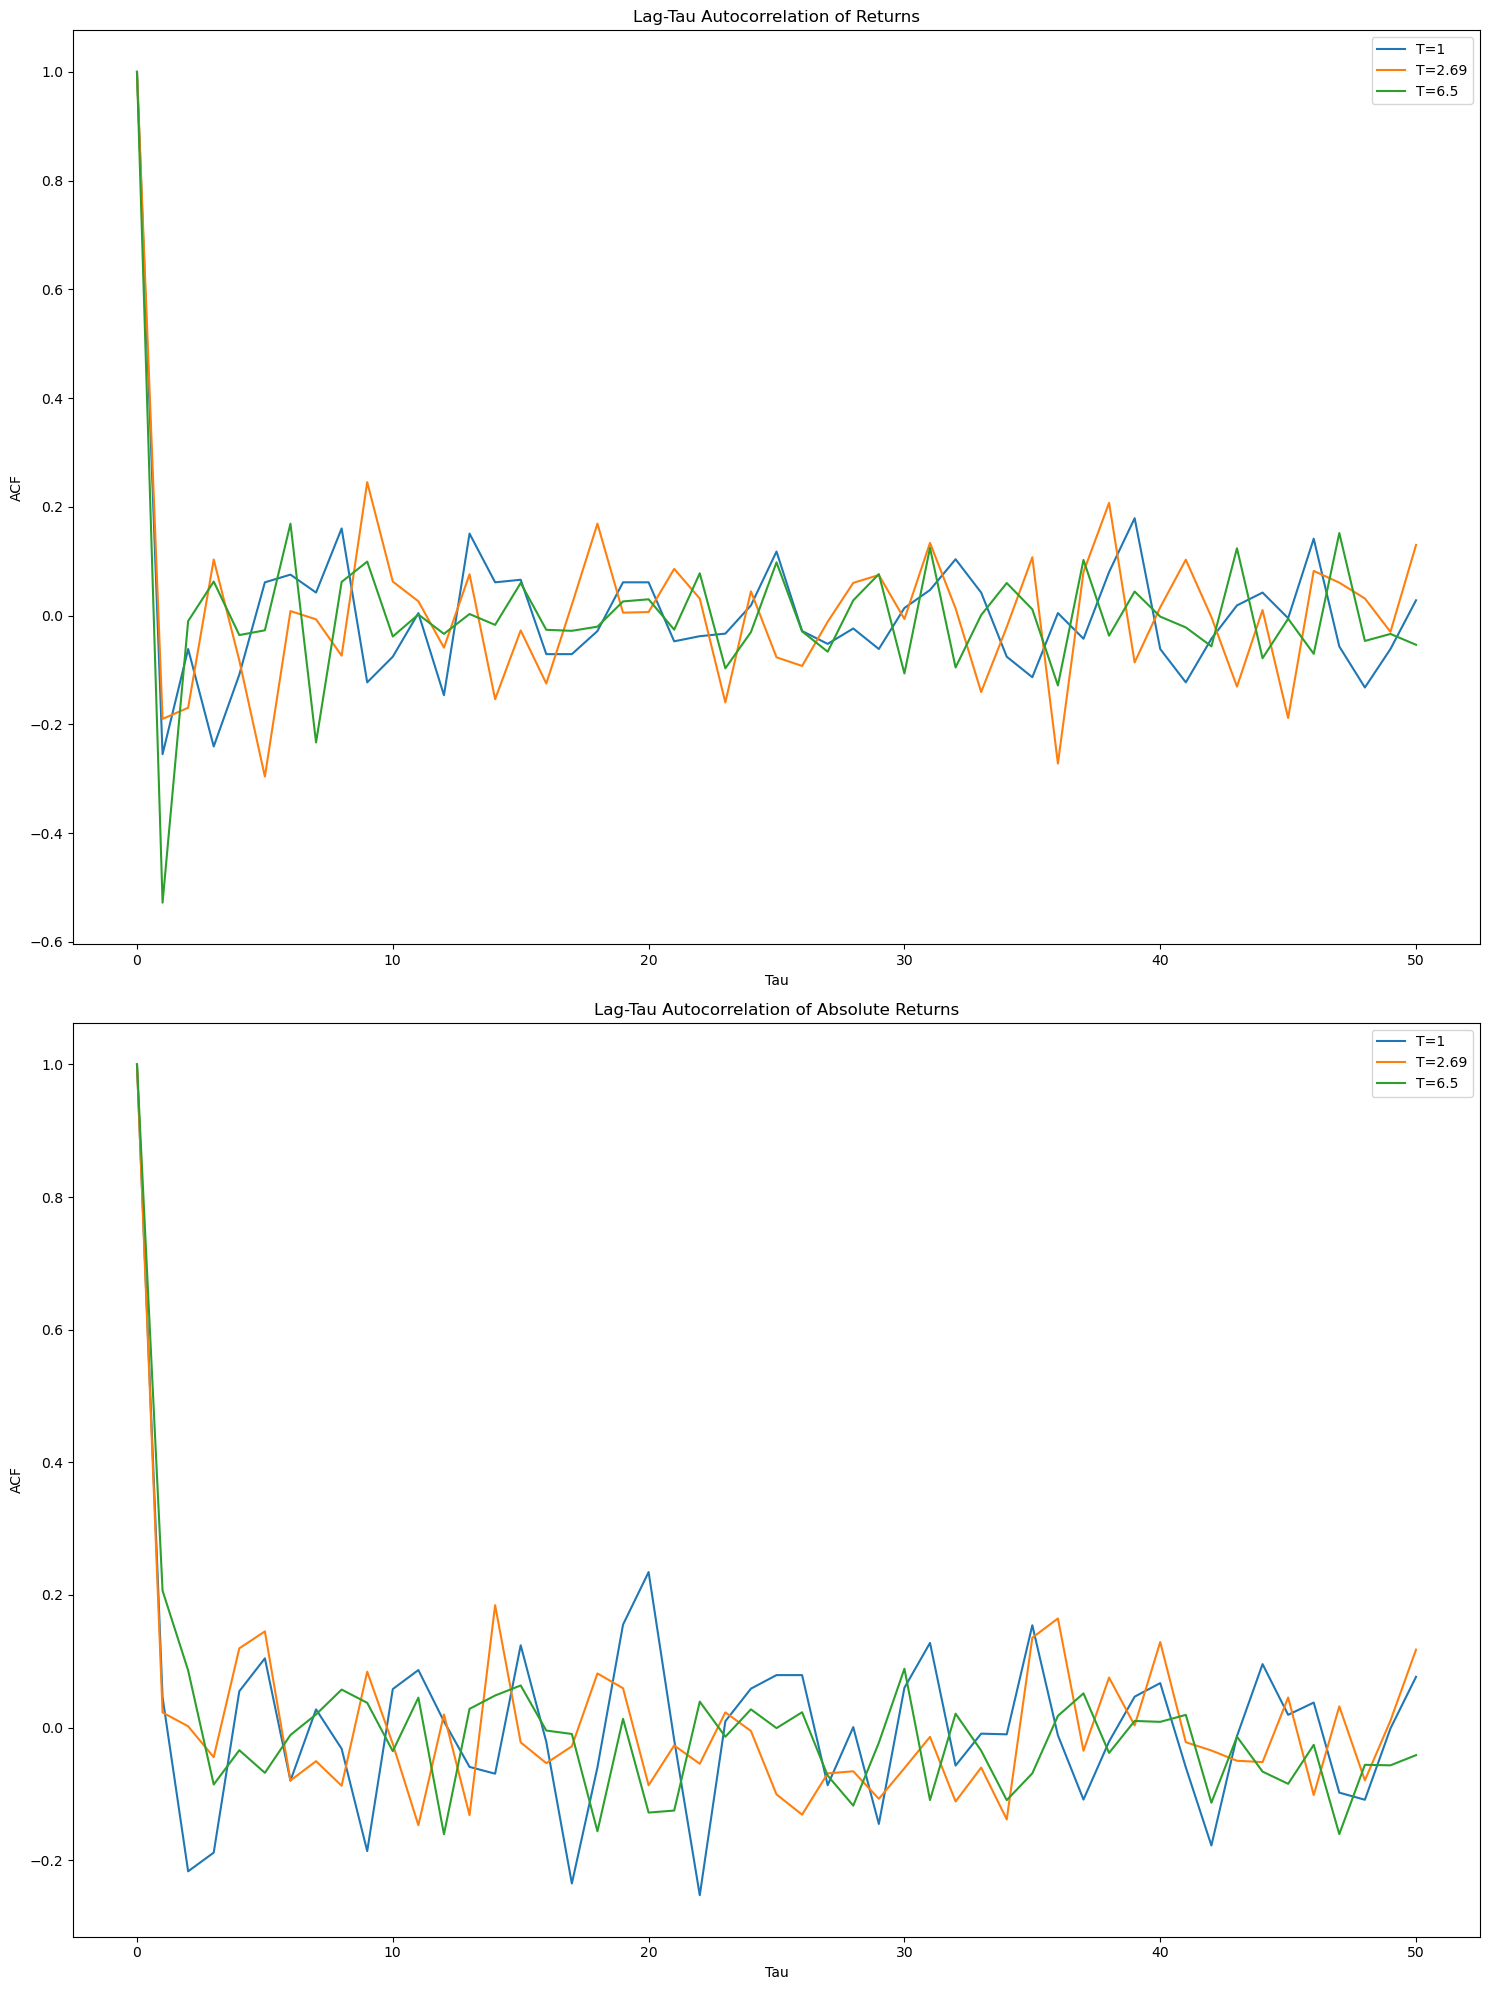

In [ ]:
#COMPUTE AND PLOT ACF (mag,returns,abs return), CORRELATION TIME, KURTOSIS


#calculate lag-Tau auto-correlation for Tau up to max_lag


def autocorrelation_function(x, max_lag):
    x = x - np.mean(x)
    result = np.correlate(x, x, mode='full')
    acf = result[result.size // 2:]
    acf = acf / acf[0]
    return acf[:max_lag+1]


acf = {}

for t in temps:
    m = np.array(results[t]["Magnetisation"])
    r = np.array(results[t]["First_Return"])
    rolling_vol = np.array(results[t]["Rolling_Vol"])

    acf_m = autocorrelation_function(m, 50)
    acf_r = autocorrelation_function(r, 50)
    acf_rolling_vol = autocorrelation_function(rolling_vol, 50)

    acf[t] = {"acf_m":acf_m,"acf_r":acf_r,"acf_rolling_vol":acf_rolling_vol}


#Plot AutoCorrelation values for Tau

fig, axes = plt.subplots(2, 1, figsize=(12, 18))
axes = axes.flatten()

plot_t = [1, 2.269, 6.5]

for t in plot_t:
    axes[0].plot(acf[t]["acf_r"], label=f"T={t}")
    axes[1].plot(acf[t]["acf_rolling_vol"], label=f"T={t}")

axes[0].set_xlabel("Tau")
axes[0].set_ylabel("ACF")
axes[0].set_title("Lag-Tau Autocorrelation of Returns")
axes[0].legend()

axes[1].set_xlabel("Tau")
axes[1].set_ylabel("ACF")
axes[1].set_title("Lag-Tau Autocorrelation of Rolling Volatility")
axes[1].legend()

plt.tight_layout()
plt.show()

